In [52]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [53]:
dataset=pd.read_csv("../Datasets/Dataset_regression.csv")
dataset

,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,income_k,rooms,crime_rate,garage_spaces,school_rating,price
0,3774.0,1.0,4.4,44.0,12.41,24.58,9.0,3.93,2.0,4.9,881889.277081
1,4107.0,5.0,NaN,25.0,34.27,113.32,3.0,3.57,2.0,6.2,752923.379433
2,1460.0,4.0,1.6,38.0,30.12,21.81,11.0,11.17,1.0,6.3,237217.344515
3,1894.0,1.0,3.8,27.0,24.84,145.98,6.0,5.14,2.0,7.9,453706.228068
4,1730.0,5.0,3.3,4.0,25.72,69.03,5.0,7.84,3.0,9.6,652759.993302
...,...,...,...,...,...,...,...,...,...,...,...
995,2084.0,1.0,2.4,40.0,15.27,121.56,NaN,13.76,2.0,8.8,582541.947060
996,2233.0,5.0,4.2,28.0,2.72,49.83,10.0,2.92,2.0,6.9,925061.912148
997,2752.0,3.0,3.5,8.0,2.34,139.90,6.0,2.26,0.0,4.3,897998.490678
998,3770.0,2.0,3.1,12.0,20.51,107.31,8.0,1.74,0.0,6.3,824286.488731


In [54]:
X=dataset.iloc[:,4:5].values
y=dataset.iloc[:,-1].values
y=y.reshape(len(y),1)


In [55]:
from sklearn.impute import SimpleImputer

si=SimpleImputer(missing_values=np.nan,strategy="mean")
si.fit(X)
X=si.fit_transform(X)

In [56]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)

sc_y=StandardScaler()
y=sc_y.fit_transform(y)

In [57]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [58]:
from sklearn.svm import SVR
regressor = SVR(kernel="rbf")

In [59]:
regressor.fit(X_train,y_train)

c:\Users\habra\OneDrive\Desktop\Work\AI_Bootcamp_Seoul\venv\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


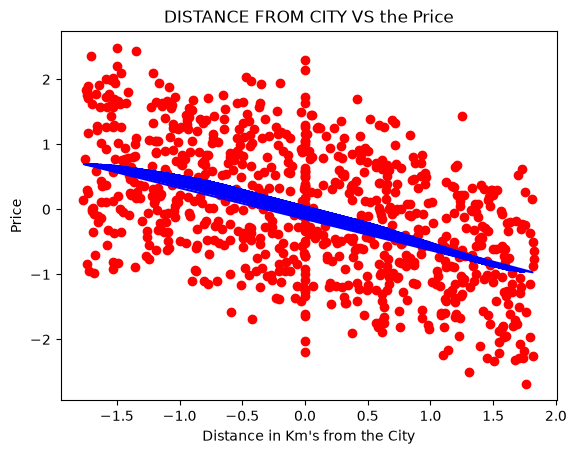

In [62]:
plt.scatter(X_train,y_train,color="red")
plt.plot(X_test,regressor.predict(X_test),color="blue")
plt.title("DISTANCE FROM CITY VS the Price")
plt.xlabel("Distance in Km's from the City")
plt.ylabel("Price")
plt.show()

In [63]:
y_preds=regressor.predict(y_test)

In [64]:

from sklearn.metrics import r2_score
r2_score(y_test,y_preds)

-1.2519685558208082